# Assignment 3: Reinforcement learning for sustainable building control

## Indoor climate control using reinforcement learning

**Group 1:** Finn, Mirko, Mohamed

The aim is to regulate indoor temperature, CO₂ concentration, and humidity while avoiding unnecessary energy use. This makes the task a sustainable operations problem, because the controller must balance comfort, air quality, and energy consumption.


In [5]:
import math
import random
from collections import deque, namedtuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)


Device: cpu


# Framing the problem and the big picture

Buildings use energy to maintain acceptable indoor conditions. Heating and ventilation are important for comfort and health, but they also increase energy consumption. A controller therefore has to manage a trade-off between indoor climate quality and sustainable operation.

In this project, the building is represented as a single indoor zone. The controller observes indoor and outdoor conditions and chooses a heating and ventilation setting at each time step.

The state contains:
- indoor temperature
- indoor CO₂ concentration
- indoor relative humidity
- outdoor temperature
- outdoor relative humidity
- occupancy
- time of day encoded with sine and cosine features

The action space is discrete. The agent chooses one of three heating levels and one of three ventilation levels. This gives nine possible actions in total.

The environment is not intended to be a complete physical building model. It is a compact simulation that captures the main control relationships needed for the assignment.


In [6]:

class BuildingClimateEnv:
    def __init__(self, episode_length=96, seed=42):
        self.episode_length = episode_length           # 96 steps => 15-minute control for 24 hours
        self.dt_hours = 0.25
        self.rng = np.random.default_rng(seed)

        self.heating_levels = [0.0, 1.5, 3.0]         # abstract heating power
        self.ventilation_levels = [0.2, 0.6, 1.0]     # air exchange intensity
        self.action_map = [(h, v) for h in range(3) for v in range(3)]

        self.temp_target_occ = 22.0
        self.temp_target_unocc = 18.0
        self.co2_target = 900.0
        self.humidity_low = 35.0
        self.humidity_high = 60.0

        self.reset()

    def _occupancy_profile(self, step):
        hour = (step * self.dt_hours) % 24.0
        # office-like weekday occupancy pattern within one simulated day
        if 8 <= hour < 18:
            if hour < 9:
                return int(4 + 6 * (hour - 8))   # ramp up
            if hour < 12:
                return 10
            if hour < 13:
                return 6                          # lunch dip
            if hour < 17:
                return 9
            return 5
        return 0

    def _outdoor_temp_profile(self, step):
        hour = (step * self.dt_hours) % 24.0
        seasonal_offset = self.rng.normal(0, 0.6)
        return 7 + 6 * math.sin((2 * math.pi / 24) * (hour - 6)) + seasonal_offset

    def _outdoor_humidity_profile(self, step):
        hour = (step * self.dt_hours) % 24.0
        base = 72 - 10 * math.sin((2 * math.pi / 24) * (hour - 5))
        return float(np.clip(base + self.rng.normal(0, 2.0), 35, 95))

    def _state(self):
        hour = (self.t * self.dt_hours) % 24.0
        occ_norm = self.occupancy / 10.0
        return np.array([
            self.indoor_temp / 30.0,
            self.indoor_humidity / 100.0,
            self.indoor_co2 / 2000.0,
            self.outdoor_temp / 30.0,
            self.outdoor_humidity / 100.0,
            occ_norm,
            math.sin(2 * math.pi * hour / 24.0),
            math.cos(2 * math.pi * hour / 24.0),
        ], dtype=np.float32)

    def reset(self):
        self.t = 0
        self.indoor_temp = float(self.rng.uniform(20.0, 24.0))
        self.indoor_humidity = float(self.rng.uniform(38.0, 55.0))
        self.indoor_co2 = float(self.rng.uniform(500.0, 900.0))
        self.occupancy = self._occupancy_profile(self.t)
        self.outdoor_temp = self._outdoor_temp_profile(self.t)
        self.outdoor_humidity = self._outdoor_humidity_profile(self.t)
        self.history = []
        return self._state()

    def step(self, action):
        heating_idx, vent_idx = self.action_map[action]
        heating = self.heating_levels[heating_idx]
        ventilation = self.ventilation_levels[vent_idx]

        hour = (self.t * self.dt_hours) % 24.0
        self.occupancy = self._occupancy_profile(self.t)
        self.outdoor_temp = self._outdoor_temp_profile(self.t)
        self.outdoor_humidity = self._outdoor_humidity_profile(self.t)

        # ---- Temperature dynamics ----
        # building loses/gains heat toward outdoor temperature
        envelope_exchange = 0.08 * (self.outdoor_temp - self.indoor_temp)
        # ventilation also moves indoor temp toward outdoor temp
        ventilation_temp_effect = 0.14 * ventilation * (self.outdoor_temp - self.indoor_temp)
        # people add a bit of heat
        occupancy_heat = 0.03 * self.occupancy
        # heating system adds controlled heat
        heating_effect = 0.55 * heating

        temp_noise = self.rng.normal(0, 0.10)
        self.indoor_temp += envelope_exchange + ventilation_temp_effect + occupancy_heat + heating_effect + temp_noise

        # ---- Humidity dynamics ----
        # ventilation pulls indoor humidity toward outdoor humidity
        humidity_mixing = 0.18 * ventilation * (self.outdoor_humidity - self.indoor_humidity)
        # occupants add moisture
        occupancy_moisture = 0.45 * self.occupancy
        # heating tends to dry the air a little
        heating_dryness = 0.65 * heating
        humidity_noise = self.rng.normal(0, 0.5)
        self.indoor_humidity += humidity_mixing + occupancy_moisture - heating_dryness + humidity_noise
        self.indoor_humidity = float(np.clip(self.indoor_humidity, 15.0, 90.0))

        # ---- CO2 dynamics ----
        # occupants produce CO2; ventilation removes it
        co2_generation = 42.0 * self.occupancy
        co2_removal = 0.22 * ventilation * (self.indoor_co2 - 420.0)
        co2_noise = self.rng.normal(0, 8.0)
        self.indoor_co2 += co2_generation - co2_removal + co2_noise
        self.indoor_co2 = float(np.clip(self.indoor_co2, 380.0, 2500.0))

        occupied = self.occupancy > 0
        temp_target = self.temp_target_occ if occupied else self.temp_target_unocc

        # ---- Exponential penalty terms ----
        # Small deviations are allowed, but severe violations grow quickly.
        # This is especially important for CO2, where delayed ventilation should be costly.
        temp_error = abs(self.indoor_temp - temp_target)
        temp_penalty = math.expm1(temp_error / 3.0)

        co2_excess = max(0.0, self.indoor_co2 - self.co2_target)
        co2_penalty = math.expm1(1.2 * co2_excess / 700.0)

        humidity_error = 0.0
        if self.indoor_humidity < self.humidity_low:
            humidity_error = self.humidity_low - self.indoor_humidity
        elif self.indoor_humidity > self.humidity_high:
            humidity_error = self.indoor_humidity - self.humidity_high
        humidity_penalty = math.expm1(1.1 * humidity_error / 20.0)

        energy_penalty = 0.55 * heating + 0.30 * ventilation

        reward = -(
            1.10 * temp_penalty +
            2.40 * co2_penalty +
            0.80 * humidity_penalty +
            0.55 * energy_penalty
        )

        self.history.append({
            "step": self.t,
            "hour": hour,
            "occupancy": self.occupancy,
            "indoor_temp": self.indoor_temp,
            "indoor_humidity": self.indoor_humidity,
            "indoor_co2": self.indoor_co2,
            "outdoor_temp": self.outdoor_temp,
            "outdoor_humidity": self.outdoor_humidity,
            "heating_idx": heating_idx,
            "vent_idx": vent_idx,
            "heating_power": heating,
            "ventilation_level": ventilation,
            "reward": reward,
            "temp_penalty": temp_penalty,
            "co2_penalty": co2_penalty,
            "humidity_penalty": humidity_penalty,
            "energy_penalty": energy_penalty,
        })

        self.t += 1
        done = self.t >= self.episode_length
        next_state = self._state()
        info = {
            "temp_penalty": temp_penalty,
            "co2_penalty": co2_penalty,
            "humidity_penalty": humidity_penalty,
            "energy_penalty": energy_penalty,
        }
        return next_state, reward, done, info

    @property
    def observation_dim(self):
        return 8

    @property
    def action_dim(self):
        return len(self.action_map)


env = BuildingClimateEnv()
state = env.reset()
print('Observation dim:', env.observation_dim)
print('Action dim:', env.action_dim)
print('Initial state:', state)



Observation dim: 8
Action dim: 9
Initial state: [0.79674965 0.50939375 0.40721285 0.03299731 0.7995317  0.
 0.         1.        ]


# Control objective and reward design

The objective is to maintain acceptable indoor conditions while limiting energy use.

The reward is defined as the negative sum of several penalty terms. These terms measure temperature discomfort, CO₂ concentration, humidity deviation, and energy use from heating and ventilation.

The CO₂, temperature, and humidity penalties use exponential scaling.

The reward design encourages the agent to avoid policies that save energy by allowing poor indoor air quality or poor thermal comfort.


In [7]:

def decode_state(state):
    indoor_temp = float(state[0] * 30.0)
    indoor_humidity = float(state[1] * 100.0)
    indoor_co2 = float(state[2] * 2000.0)
    outdoor_temp = float(state[3] * 30.0)
    outdoor_humidity = float(state[4] * 100.0)
    occupancy = int(round(state[5] * 10.0))
    return indoor_temp, indoor_humidity, indoor_co2, outdoor_temp, outdoor_humidity, occupancy

def action_id(heating_idx, vent_idx):
    return heating_idx * 3 + vent_idx

def random_policy(state):
    return random.randint(0, 8)

def rule_based_policy(state):
    indoor_temp, indoor_humidity, indoor_co2, outdoor_temp, outdoor_humidity, occupancy = decode_state(state)

    if occupancy > 0:
        if indoor_temp < 21.0:
            h = 2
        elif indoor_temp < 22.0:
            h = 1
        else:
            h = 0
    else:
        if indoor_temp < 18.0:
            h = 1
        else:
            h = 0

    if indoor_co2 > 1100:
        v = 2
    elif indoor_co2 > 850:
        v = 1
    else:
        v = 0

    return action_id(h, v)

def energy_saver_policy(state):
    indoor_temp, indoor_humidity, indoor_co2, outdoor_temp, outdoor_humidity, occupancy = decode_state(state)

    if occupancy > 0 and indoor_temp < 20.5:
        h = 1 if outdoor_temp > 0 else 2
    elif occupancy == 0 and indoor_temp < 17.0:
        h = 1
    else:
        h = 0

    if indoor_co2 > 1200:
        v = 2
    elif indoor_co2 > 1000:
        v = 1
    else:
        v = 0

    return action_id(h, v)

def air_quality_policy(state):
    indoor_temp, indoor_humidity, indoor_co2, outdoor_temp, outdoor_humidity, occupancy = decode_state(state)

    if occupancy > 0 and indoor_temp < 21.5:
        h = 2 if outdoor_temp < 5 else 1
    elif occupancy == 0 and indoor_temp < 18.0:
        h = 1
    else:
        h = 0

    if indoor_co2 > 900:
        v = 2
    elif indoor_co2 > 700:
        v = 1
    else:
        v = 0

    return action_id(h, v)

baseline_policies = {
    "Random": random_policy,
    "RuleBased": rule_based_policy,
    "EnergySaver": energy_saver_policy,
    "AirQuality": air_quality_policy,
}
print(list(baseline_policies.keys()))


['Random', 'RuleBased', 'EnergySaver', 'AirQuality']


# Baseline methods

The learned policy is compared with four baseline controllers.

Random policy

The action is selected uniformly at random. This gives a lower reference point for performance.

Rule-based controller

Heating and ventilation are adjusted using fixed thresholds for temperature and CO₂. This represents a simple hand-designed building controller.

Energy-saving controller

This controller uses low heating and ventilation whenever possible. It is included to show the cost of focusing too strongly on energy reduction.

Air-quality-first controller

This controller ventilates more aggressively when CO₂ increases. It is included to show the opposite trade-off, where indoor air quality is prioritized over energy consumption.


In [8]:

Transition = namedtuple("Transition", ["state", "action", "reward", "next_state", "done"])

class ReplayBuffer:
    def __init__(self, capacity=20000):
        self.buffer = deque(maxlen=capacity)

    def push(self, *args):
        self.buffer.append(Transition(*args))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        return Transition(*zip(*batch))

    def __len__(self):
        return len(self.buffer)

class QNetwork(nn.Module):
    def __init__(self, state_dim, action_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, action_dim)
        )

    def forward(self, x):
        return self.net(x)

class DQNAgent:
    def __init__(
        self,
        state_dim,
        action_dim,
        lr=1e-3,
        gamma=0.99,
        epsilon_start=1.0,
        epsilon_end=0.05,
        epsilon_decay=0.985,
        batch_size=64,
        target_update=10,
        buffer_capacity=20000,
    ):
        self.state_dim = state_dim
        self.action_dim = action_dim
        self.gamma = gamma
        self.epsilon = epsilon_start
        self.epsilon_end = epsilon_end
        self.epsilon_decay = epsilon_decay
        self.batch_size = batch_size
        self.target_update = target_update

        self.policy_net = QNetwork(state_dim, action_dim).to(DEVICE)
        self.target_net = QNetwork(state_dim, action_dim).to(DEVICE)
        self.target_net.load_state_dict(self.policy_net.state_dict())
        self.target_net.eval()

        self.optimizer = optim.Adam(self.policy_net.parameters(), lr=lr)
        self.memory = ReplayBuffer(capacity=buffer_capacity)
        self.learn_steps = 0

    def select_action(self, state, greedy=False):
        if (not greedy) and random.random() < self.epsilon:
            return random.randrange(self.action_dim)

        with torch.no_grad():
            state_t = torch.tensor(state, dtype=torch.float32, device=DEVICE).unsqueeze(0)
            q_values = self.policy_net(state_t)
            return int(torch.argmax(q_values, dim=1).item())

    def store(self, state, action, reward, next_state, done):
        self.memory.push(state, action, reward, next_state, done)

    def train_step(self):
        if len(self.memory) < self.batch_size:
            return None

        batch = self.memory.sample(self.batch_size)

        state_batch = torch.tensor(np.array(batch.state), dtype=torch.float32, device=DEVICE)
        action_batch = torch.tensor(batch.action, dtype=torch.int64, device=DEVICE).unsqueeze(1)
        reward_batch = torch.tensor(batch.reward, dtype=torch.float32, device=DEVICE).unsqueeze(1)
        next_state_batch = torch.tensor(np.array(batch.next_state), dtype=torch.float32, device=DEVICE)
        done_batch = torch.tensor(batch.done, dtype=torch.float32, device=DEVICE).unsqueeze(1)

        q_values = self.policy_net(state_batch).gather(1, action_batch)

        with torch.no_grad():
            max_next_q = self.target_net(next_state_batch).max(dim=1, keepdim=True)[0]
            target_q = reward_batch + self.gamma * max_next_q * (1.0 - done_batch)

        loss = nn.MSELoss()(q_values, target_q)

        self.optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(self.policy_net.parameters(), max_norm=5.0)
        self.optimizer.step()

        self.learn_steps += 1
        return float(loss.item())

    def end_episode(self, episode_idx):
        self.epsilon = max(self.epsilon_end, self.epsilon * self.epsilon_decay)
        if (episode_idx + 1) % self.target_update == 0:
            self.target_net.load_state_dict(self.policy_net.state_dict())


# Reinforcement learning method

The agent is trained using a Deep Q-Network implemented in PyTorch.

A DQN is suitable here because the state variables are continuous, while the action space is discrete. The neural network approximates the action-value function. For each state, it outputs one value for each possible combination of heating and ventilation.

Training uses experience replay and a target network. Experience replay stores previous transitions and samples them randomly during training. The target network is updated periodically to make learning more stable.

The agent uses epsilon-greedy exploration. At the start of training it often explores random actions. Over time, exploration is reduced and the policy increasingly follows the learned Q-values.


In [9]:

def run_episode(env, policy_fn=None, agent=None, train=False):
    state = env.reset()
    done = False
    total_reward = 0.0
    losses = []

    while not done:
        if agent is not None:
            action = agent.select_action(state, greedy=not train)
        else:
            action = policy_fn(state)

        next_state, reward, done, info = env.step(action)

        if train and agent is not None:
            agent.store(state, action, reward, next_state, done)
            loss = agent.train_step()
            if loss is not None:
                losses.append(loss)

        total_reward += reward
        state = next_state

    history = pd.DataFrame(env.history)
    metrics = {
        "episode_reward": total_reward,
        "avg_temp_penalty": history["temp_penalty"].mean(),
        "avg_co2_penalty": history["co2_penalty"].mean(),
        "avg_humidity_penalty": history["humidity_penalty"].mean(),
        "avg_energy_penalty": history["energy_penalty"].mean(),
        "avg_indoor_temp": history["indoor_temp"].mean(),
        "avg_indoor_co2": history["indoor_co2"].mean(),
        "avg_indoor_humidity": history["indoor_humidity"].mean(),
        "max_indoor_co2": history["indoor_co2"].max(),
        "comfort_ok_share": ((history["indoor_temp"].between(21, 23)) &
                             (history["indoor_co2"] <= 1000) &
                             (history["indoor_humidity"].between(35, 60))).mean()
    }
    if losses:
        metrics["avg_loss"] = float(np.mean(losses))
    return metrics, history

def train_dqn(
    episodes=250,
    episode_length=96,
    lr=1e-3,
    gamma=0.99,
):
    env = BuildingClimateEnv(episode_length=episode_length, seed=SEED)
    agent = DQNAgent(
        state_dim=env.observation_dim,
        action_dim=env.action_dim,
        lr=lr,
        gamma=gamma,
        epsilon_start=1.0,
        epsilon_end=0.05,
        epsilon_decay=0.985,
        batch_size=64,
        target_update=10,
        buffer_capacity=25000,
    )

    records = []
    for ep in range(episodes):
        metrics, _ = run_episode(env, agent=agent, train=True)
        agent.end_episode(ep)
        metrics["episode"] = ep + 1
        metrics["epsilon"] = agent.epsilon
        records.append(metrics)

        if (ep + 1) % 20 == 0:
            print(
                f"Episode {ep+1:3d} | reward {metrics['episode_reward']:.1f} | "
                f"temp {metrics['avg_temp_penalty']:.2f} | "
                f"co2 {metrics['avg_co2_penalty']:.2f} | "
                f"energy {metrics['avg_energy_penalty']:.2f} | "
                f"eps {agent.epsilon:.3f}"
            )

    training_df = pd.DataFrame(records)
    return agent, training_df


# Training the DQN agent

The agent is trained over multiple simulated episodes. One episode corresponds to one day of building operation with 15-minute control intervals.

The default number of episodes is kept moderate so the notebook can run on a typical laptop. If runtime is an issue, the number of training episodes can be reduced.


In [10]:
agent, training_df = train_dqn(episodes=180, episode_length=96)
training_df.tail()



Episode  20 | reward -2109.4 | temp 8.21 | co2 4.68 | energy 1.22 | eps 0.739
Episode  40 | reward -1388.3 | temp 3.82 | co2 3.62 | energy 1.33 | eps 0.546
Episode  60 | reward -1266.0 | temp 2.18 | co2 3.88 | energy 1.41 | eps 0.404
Episode  80 | reward -1218.6 | temp 2.35 | co2 3.64 | energy 1.53 | eps 0.298
Episode 100 | reward -1053.5 | temp 1.56 | co2 3.25 | energy 1.58 | eps 0.221
Episode 120 | reward -889.3 | temp 0.55 | co2 3.06 | energy 1.63 | eps 0.163
Episode 140 | reward -812.3 | temp 0.59 | co2 2.66 | energy 1.70 | eps 0.121
Episode 160 | reward -833.3 | temp 0.69 | co2 2.71 | energy 1.71 | eps 0.089
Episode 180 | reward -797.0 | temp 0.89 | co2 2.48 | energy 1.70 | eps 0.066


,episode_reward,avg_temp_penalty,avg_co2_penalty,avg_humidity_penalty,avg_energy_penalty,avg_indoor_temp,avg_indoor_co2,avg_indoor_humidity,max_indoor_co2,comfort_ok_share,avg_loss,episode,epsilon
175,-814.847033,1.010415,2.497978,0.547239,1.715625,18.399053,1182.655833,59.090951,2323.231719,0.000000,16.675450,176,0.069948
176,-842.109135,0.708508,2.777132,0.459788,1.744844,18.968306,1267.649391,57.528276,2427.569110,0.000000,18.684583,177,0.068899
177,-775.685445,0.783168,2.428786,0.521056,1.768438,18.678016,1164.665187,57.587286,2274.125756,0.000000,17.965966,178,0.067865
178,-794.835183,0.732870,2.547848,0.513636,1.722969,18.392446,1193.351419,59.982612,2500.000000,0.010417,16.732889,179,0.066848
179,-797.022400,0.885426,2.481742,0.545170,1.701875,18.944194,1265.527545,57.943797,2290.460919,0.000000,16.758497,180,0.065845


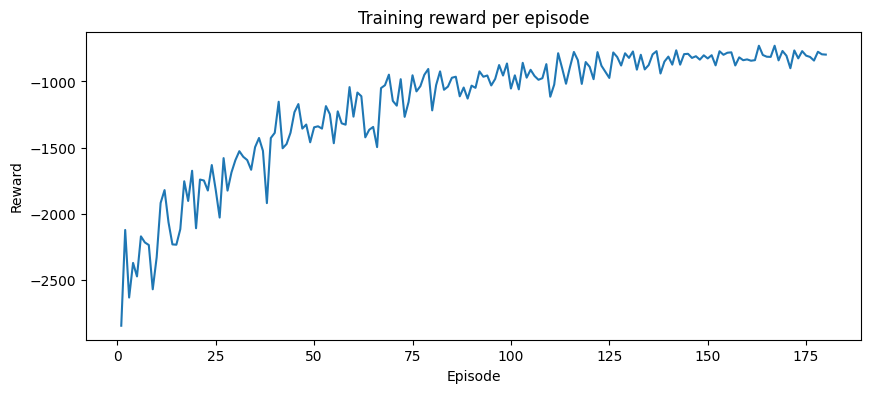

In [11]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(training_df['episode'], training_df['episode_reward'])
ax.set_title('Training reward per episode')
ax.set_xlabel('Episode')
ax.set_ylabel('Reward')
plt.show()


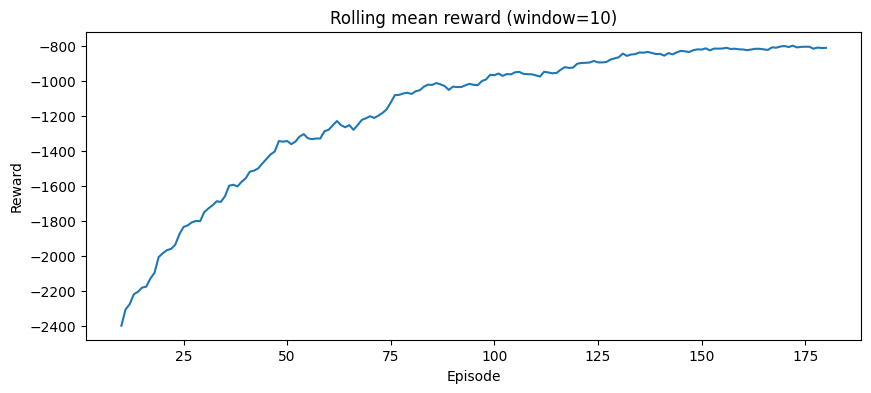

In [12]:
rolling = training_df['episode_reward'].rolling(10).mean()
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(training_df['episode'], rolling)
ax.set_title('Rolling mean reward (window=10)')
ax.set_xlabel('Episode')
ax.set_ylabel('Reward')
plt.show()


# Evaluation setup

After training, the learned policy is evaluated against the baseline controllers.

Each controller is tested over several episodes with different random seeds. The following metrics are recorded:
- cumulative reward
- average temperature penalty
- average CO₂ penalty
- average humidity penalty
- average energy penalty
- share of time steps where comfort conditions are acceptable

These metrics make it possible to compare both sustainability and indoor climate performance.


In [13]:

def evaluate_policy(name, policy_fn=None, agent=None, n_episodes=40, episode_length=96):
    all_metrics = []
    histories = []

    for ep in range(n_episodes):
        env = BuildingClimateEnv(episode_length=episode_length, seed=SEED + ep + 1000)
        if agent is not None:
            metrics, history = run_episode(env, agent=agent, train=False)
        else:
            metrics, history = run_episode(env, policy_fn=policy_fn, agent=None, train=False)
        all_metrics.append(metrics)
        histories.append(history)

    summary = pd.DataFrame(all_metrics).mean(numeric_only=True).to_dict()
    summary["policy"] = name
    return summary, histories

results = []
policy_histories = {}

for name, fn in baseline_policies.items():
    summary, histories = evaluate_policy(name, policy_fn=fn, n_episodes=40)
    results.append(summary)
    policy_histories[name] = histories

dqn_summary, dqn_histories = evaluate_policy("DQN", agent=agent, n_episodes=40)
results.append(dqn_summary)
policy_histories["DQN"] = dqn_histories

results_df = pd.DataFrame(results)
results_df = results_df[
    ["policy", "episode_reward", "comfort_ok_share", "avg_temp_penalty",
     "avg_co2_penalty", "avg_humidity_penalty", "avg_energy_penalty",
     "avg_indoor_temp", "avg_indoor_co2", "avg_indoor_humidity", "max_indoor_co2"]
].sort_values("episode_reward", ascending=False)

results_df


,policy,episode_reward,comfort_ok_share,avg_temp_penalty,avg_co2_penalty,avg_humidity_penalty,avg_energy_penalty,avg_indoor_temp,avg_indoor_co2,avg_indoor_humidity,max_indoor_co2
4,DQN,-731.092917,0.000521,0.594926,2.322414,0.496449,1.800328,19.326983,1207.238010,56.227490,2276.619797
1,RuleBased,-1075.103545,0.000260,4.006993,2.331910,0.605665,1.291250,15.588060,1178.908238,63.290402,2280.445195
2,EnergySaver,-1313.581599,0.000260,6.153137,2.357799,0.909883,0.960121,14.116346,1200.780029,65.671977,2283.140455
3,AirQuality,-1385.118259,0.000260,6.906790,2.312634,0.928278,0.978004,13.856390,1155.529555,66.332036,2278.039945
0,Random,-2535.506321,0.001563,12.029362,4.720048,1.627361,0.998586,13.346059,1304.227695,74.195192,2500.000000


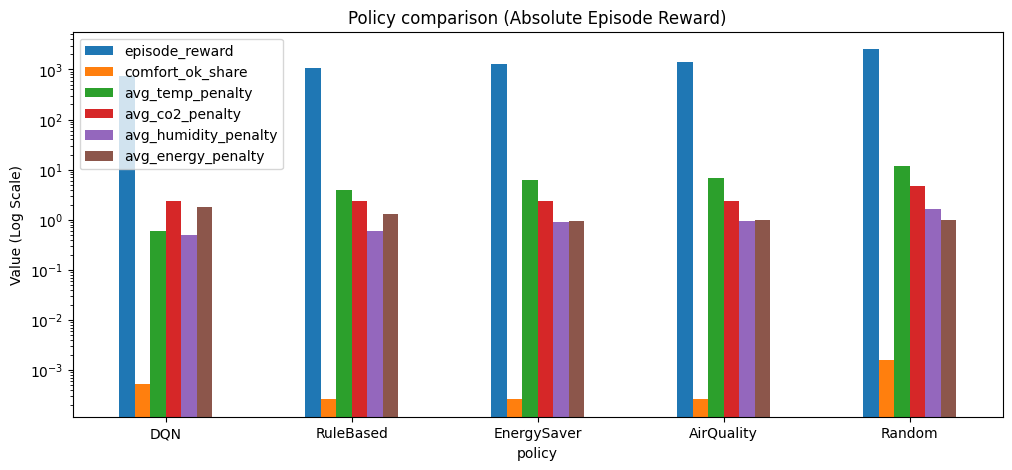

In [17]:
display_cols = ['episode_reward', 'comfort_ok_share', 'avg_temp_penalty', 'avg_co2_penalty', 'avg_humidity_penalty', 'avg_energy_penalty']
plot_df = results_df.set_index('policy')[display_cols].copy()
plot_df['episode_reward'] = plot_df['episode_reward'].abs() # Plot absolute value for log scale
ax = plot_df.plot(kind='bar', figsize=(12, 5))
plt.title('Policy comparison (Absolute Episode Reward)')
plt.ylabel('Value (Log Scale)')
plt.xticks(rotation=0)
ax.set_yscale('log')
plt.show()

# Policy comparison on a linear scale

The previous plot can be difficult to interpret if some penalty values are much larger than others. The same results are therefore also shown on a linear scale.


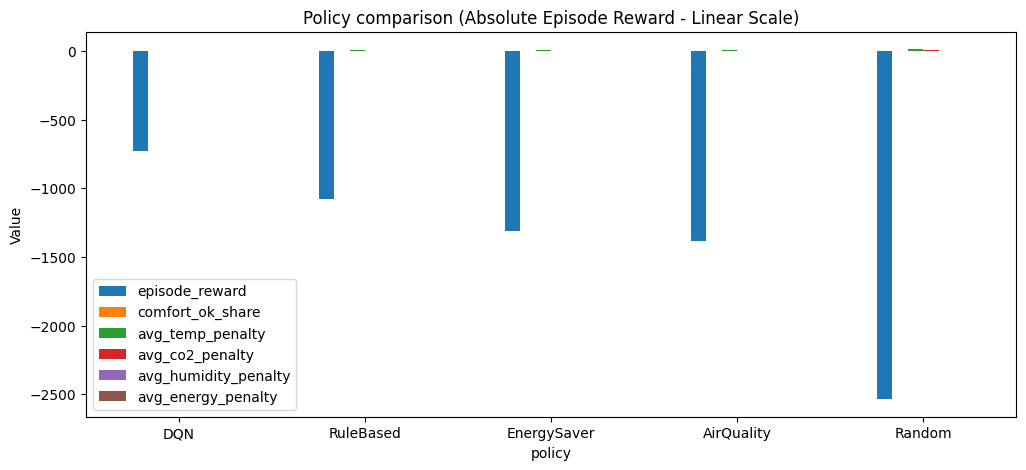

In [15]:
display_cols = ['episode_reward', 'comfort_ok_share', 'avg_temp_penalty', 'avg_co2_penalty', 'avg_humidity_penalty', 'avg_energy_penalty']
plot_df_linear = results_df.set_index('policy')[display_cols].copy()
plot_df_linear['episode_reward'] = plot_df_linear['episode_reward']
ax_linear = plot_df_linear.plot(kind='bar', figsize=(12, 5))
plt.title('Policy comparison (Absolute Episode Reward - Linear Scale)')
plt.ylabel('Value')
plt.xticks(rotation=0)
plt.show()

# Visualising one day of control behaviour

The following plots show one simulated day controlled by the learned DQN policy. The episode plot is useful for understanding whether the controller reacts sensibly over time, not only whether it achieves a good average score.

The plot includes indoor and outdoor temperature, indoor CO₂, indoor and outdoor humidity, occupancy, and the selected heating and ventilation levels.


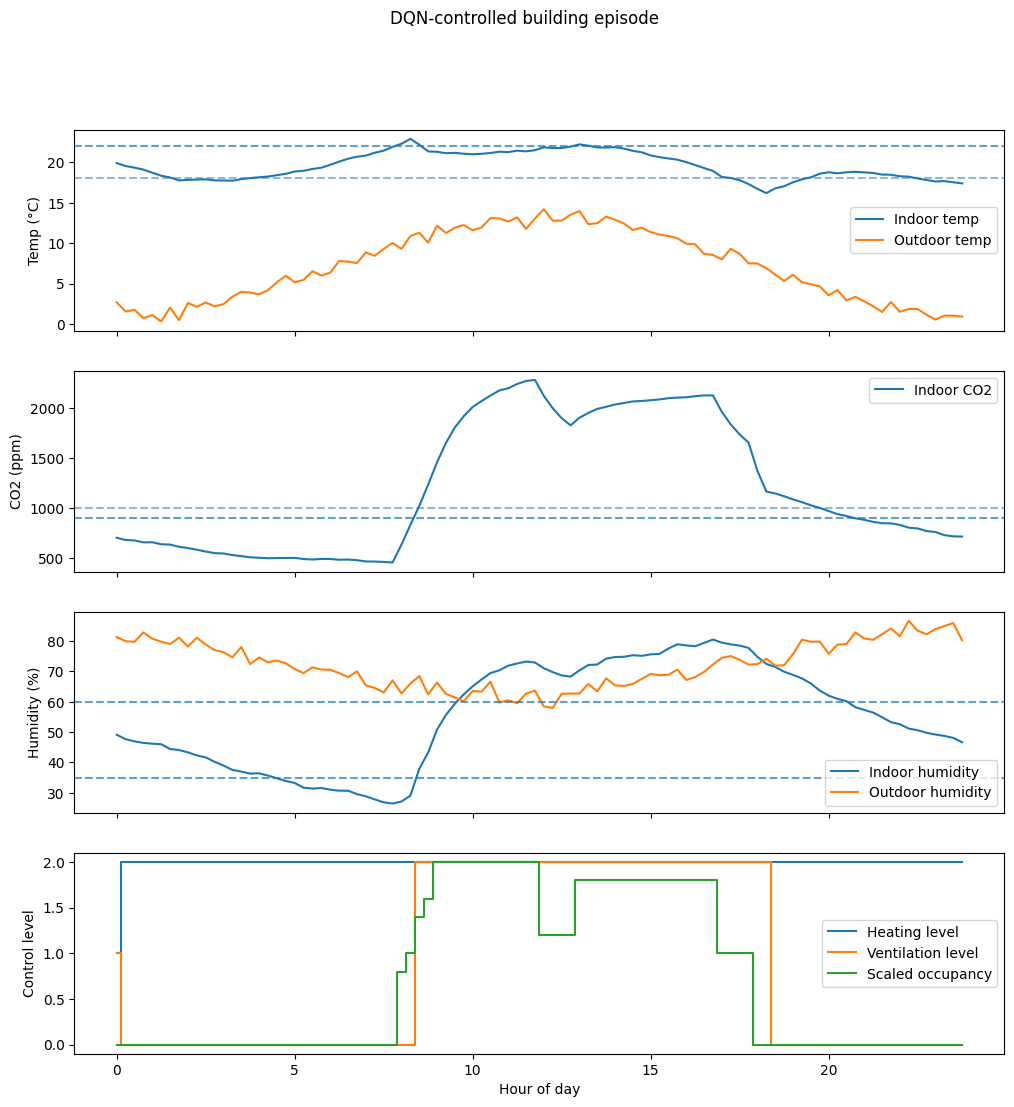

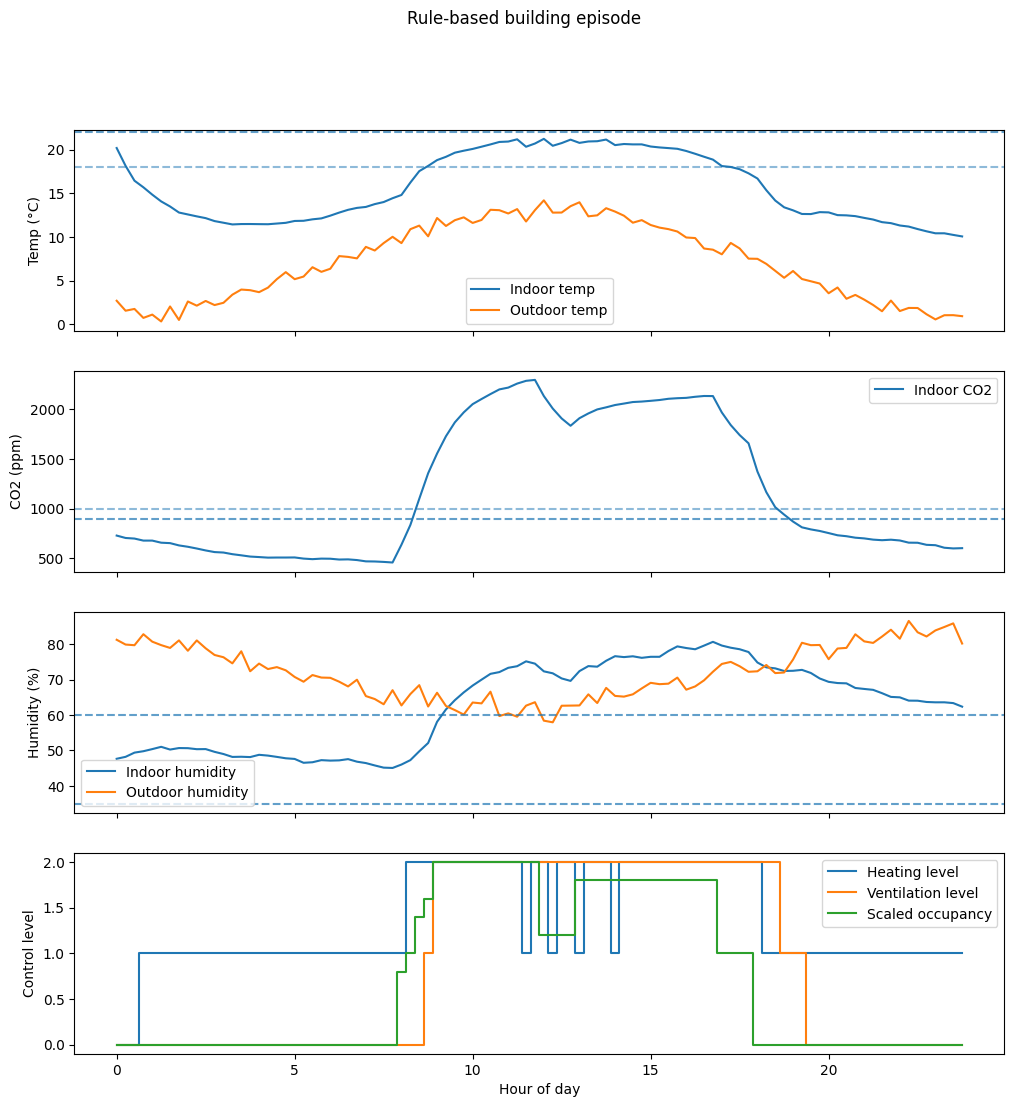

In [16]:

def plot_episode(history, title):
    fig, axes = plt.subplots(4, 1, figsize=(12, 12), sharex=True)

    x = history["hour"]
    axes[0].plot(x, history["indoor_temp"], label="Indoor temp")
    axes[0].plot(x, history["outdoor_temp"], label="Outdoor temp")
    axes[0].axhline(22, linestyle="--", alpha=0.7)
    axes[0].axhline(18, linestyle="--", alpha=0.5)
    axes[0].set_ylabel("Temp (°C)")
    axes[0].legend()

    axes[1].plot(x, history["indoor_co2"], label="Indoor CO2")
    axes[1].axhline(900, linestyle="--", alpha=0.7)
    axes[1].axhline(1000, linestyle="--", alpha=0.5)
    axes[1].set_ylabel("CO2 (ppm)")
    axes[1].legend()

    axes[2].plot(x, history["indoor_humidity"], label="Indoor humidity")
    axes[2].plot(x, history["outdoor_humidity"], label="Outdoor humidity")
    axes[2].axhline(35, linestyle="--", alpha=0.7)
    axes[2].axhline(60, linestyle="--", alpha=0.7)
    axes[2].set_ylabel("Humidity (%)")
    axes[2].legend()

    axes[3].step(x, history["heating_idx"], where="mid", label="Heating level")
    axes[3].step(x, history["vent_idx"], where="mid", label="Ventilation level")
    axes[3].step(x, history["occupancy"] / 5.0, where="mid", label="Scaled occupancy")
    axes[3].set_ylabel("Control level")
    axes[3].set_xlabel("Hour of day")
    axes[3].legend()

    fig.suptitle(title)
    plt.show()

best_dqn_history = dqn_histories[0]
baseline_history = policy_histories["RuleBased"][0]

plot_episode(best_dqn_history, "DQN-controlled building episode")
plot_episode(baseline_history, "Rule-based building episode")


# Interpreting the results

The expected result is not perfect control of every variable. The task contains competing objectives, so a good policy should balance temperature comfort, air quality, humidity, and energy use.

A useful learned policy should show the following behaviour:
- it should avoid long periods of high CO₂ concentration
- it should keep temperature close to the occupied and unoccupied targets
- it should keep humidity within a reasonable range when possible
- it should avoid unnecessary heating and ventilation

The exponential penalty terms make large violations more visible in the reward. This should push the agent to react earlier to CO₂ buildup and other severe comfort violations.

# Discussion

The simulation shows how reinforcement learning can be used for sustainable building operation. The learned controller receives information about indoor conditions, outdoor conditions, occupancy, and time of day. Based on this information, it learns when to heat and when to ventilate.

The model is simplified. It does not include detailed thermodynamics, multiple rooms, real weather data, or complex occupancy behaviour. However, it captures the main trade-offs needed for this assignment.

A limitation is that the learned policy can still be reactive. For example, the agent may increase ventilation after CO₂ has already risen. This could be improved by training for more episodes, increasing the weight of the CO₂ penalty, or adding a prediction of future occupancy.

# Conclusion

This notebook implemented a simulated environment and a PyTorch DQN agent for sustainable building control. The agent controls heating and ventilation to balance energy use, temperature comfort, CO₂ concentration, and humidity.

The evaluation compares the learned policy against several baseline methods. This makes it possible to assess whether the RL agent learns a better control strategy than simple fixed rules.

Future work could extend the environment with more realistic building dynamics, varying energy prices, seasonal weather profiles, and continuous control actions.
